# A and A_c singular value plots

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

from graspologic.embed import AdjacencySpectralEmbed
from graspologic.simulations import sbm
from graspologic.plot import heatmap, pairplot

import warnings
warnings.filterwarnings('ignore')
np.random.seed(8889)
import matplotlib.lines as mlines
%matplotlib inline

import networkx as nx
from scipy.sparse import csr_array
from graspologic.simulations import rdpg
#from scipy.linalg import irlba
#from scipy.spatial import procrustes
%run GraphEncoder.ipynb
import leidenalg as la
import igraph as ig
import scipy.sparse as sp
import random
import math
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from gae.layers import GraphConvolution
from gae.model import GCNModelVAE
from gae.utils import load_data, mask_test_edges, preprocess_graph, get_roc_score
from gae.optimizer import loss_function

/Users/tongqi/miniforge3/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/tongqi/miniforge3/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/tongqi/miniforge3/lib/python3.9/site-packages/umap/distances.py:1086: NumbaDeprecatio

In [3]:
# Define a function for dot product sampling
def sample_dot_product(lpvs):
        num_nodes = lpvs.shape[1]
        similarity_matrix = np.dot(lpvs.T, lpvs)
        np.fill_diagonal(similarity_matrix, 0)  # Remove self-similarity
        return nx.Graph(similarity_matrix)

def adj_to_edg(A):
    """
      input is the symmetric adjacency matrix: A
      other variables in this function:
      s: number of edges
      return edg_list -- matrix format with shape(edg_sum,3):
      example row in edg_list(matrix): [vertex1, vertex2, connection weight from Adj matrix]
    """
    # check the len of the second dimenson of A
    if A.shape[1] <= 3:
      edg = A
    else:
      n = A.shape[0]
      # construct the initial edgg_list matrix with the size of (edg_sum, 3)
      edg_list = []
      for i in range(n):
        for j in range(i, n):
          if A[i,j] > 0:
            row = [i, j, A[i,j]]
            edg_list.append(row)
      edg = np.array(edg_list)
    return edg

def procrustes(X, Y, type="I"):
    if type == "C":
        X = X / np.linalg.norm(X, "fro") * np.sqrt(X.shape[0])
        Y = Y / np.linalg.norm(Y, "fro") * np.sqrt(Y.shape[0])
    if type == "D":
        tX = np.sum(X ** 2, axis=1)
        tX[tX <= 1e-15] = 1
        tY = np.sum(Y ** 2, axis=1)
        tY[tY <= 1e-15] = 1
        X = X / np.sqrt(tX)[:, np.newaxis]
        Y = Y / np.sqrt(tY)[:, np.newaxis]

    tmp = X.T @ Y
    U, s, Vt = np.linalg.svd(tmp,full_matrices=True)
    W = U @ Vt ########
    error = np.linalg.norm(X @ W - Y, "fro")
    
    return {"error": error, "W": W}

def GCN_emb(model, features, adj_norm_matrix, adj_label,n, decay,learning_rate, epochs = 200):
    optimizer = torch.optim.Adam(
      model.parameters(),
      lr=learning_rate,
      weight_decay=decay) #weight decay is important!

    # get class weight
    pos_weight = ((adj_label.shape[0] * adj_label.shape[0] - adj_label.sum()) / adj_label.sum())
    # get adj norm
    adj_norm = adj_label.shape[0] * adj_label.shape[0] / float((adj_label.shape[0] *adj_label.shape[0] - adj_label.sum()) * 2)

    # Training the VAE   
    while True: #we can try 20 different random weight init runs to get an average 
        # initialize weights randomly => impact on convergence
        model.gc1.reset_parameters()
        model.gc2.reset_parameters()
        model.gc3.reset_parameters()  
        # Training
        for epoch in range(0, epochs + 1):
            model.train()
            optimizer.zero_grad()
            # ===================forward=====================
            adj_hat, mu, logvar = model(features,adj_norm_matrix)        
            loss = loss_function(adj_hat,adj_label,mu,logvar,n,adj_norm,pos_weight) #might reduce the KL term regularization
            # log
            if epoch == 0:
              init_loss = loss.item()
            # if epoch% 50 == 0:
            #   print('loss: ', loss.item())
            # ===================backward====================
            loss.backward()
            optimizer.step()
        # Check convergence
        if (init_loss-loss.item())/loss.item() > 0.05: 
            break
        else:
          print(model)
          print('not converged yet, reset params and rerun')

  # Get GCN embedding
    with torch.no_grad():
      model.eval()
      adj_hat, mu, logvar = model(features, adj_norm_matrix)
      z = model.reparameterize(mu, logvar) 

    return z

def sparse_mx_to_torch_sparse_tensor(sparse_mx):
    """Convert a scipy sparse matrix to a torch sparse tensor."""
    sparse_mx = sparse_mx.tocoo().astype(np.float32)
    indices = torch.from_numpy(
        np.vstack((sparse_mx.row, sparse_mx.col)).astype(np.int64))
    values = torch.from_numpy(sparse_mx.data)
    shape = torch.Size(sparse_mx.shape)
    return torch.sparse.FloatTensor(indices, values, shape)

def preprocess_graph(adj_):
    rowsum = np.array(adj_.sum(1))
    degree_mat_inv_sqrt = sp.diags(np.power(rowsum, -0.5).flatten()) #D^-0.5
    adj_normalized = adj_.dot(degree_mat_inv_sqrt).transpose().dot(degree_mat_inv_sqrt).tocoo()  #D^-0.5 A D^-0.5
    return sparse_mx_to_torch_sparse_tensor(adj_normalized), sparse_mx_to_torch_sparse_tensor(adj_)

def adj_in_out(adj):
    row, col = np.where(adj)
    coo = np.rec.fromarrays([row, col, adj[row, col]], names='row col value'.split())
    out = sp.coo_matrix((coo['value'], (coo['row'], coo['col'])), (adj.shape[0], adj.shape[1]))
    #Adjacency normalized matrix and label for GVAE usage
    adj_norm_matrix, adj_matrix = preprocess_graph(out)
    adj_label = torch.FloatTensor(out.toarray())
    return adj_norm_matrix, adj_matrix, adj_label#, out

def ARDPG(n,k):
    A = np.zeros((n,n))
    X = np.random.uniform(0.0, 1.0, (n,1))
    for i in range(0,n):
        if y[i] == 1:
            X[i,:] = np.random.beta(1,3)
        elif y[i] == 2:
            X[i,:] = np.random.beta(3,3)
        else:
            X[i,:] = np.random.beta(3,1)
    P=np.matmul(X,X.transpose())
    for i in range(0,n):
        for j in range(1,n):
            A[i,j]=np.random.binomial(1,P[i,j])
    for i in range(0,n):
        for j in range(0,i):
            A[i,j] = A[j,i]
            A[i,i]=0
    return A

def gety(n):
    y = np.zeros((n,1))
    #np.random.seed(2)
    for i in range(0,n):
        y[i,0] = np.random.choice(np.arange(1, 4), p=[0.2, 0.3,0.5])
    return(y)

def latent3y(n):
    X1 = np.random.dirichlet((2,1,1),int(n/3))
    X2 = np.random.dirichlet((1,1,2),int(n/3))
    X3 = np.random.dirichlet((1,2,1),(n-int(n/3)*2))
    together = np.concatenate((X1, X2,X3))
    latent = np.delete(together, 2, 1)
    ty = [1,2,3]
    y = np.repeat(ty, n/3)
    return(latent,y)
  

In [59]:
# no cluster RDPG

nvs = np.arange(100, 1501, 200 )

sim = 50
random.seed(118)

ASE_dist = []
ASE_nml = []
GEE_dist = []
GEE_nml = []
GAE_dist = []
GAE_nml = []
n_vs = []

GEE_fnorm = []
GAE_fnorm = []

GEE_dist2 = []
GEE_fnorm2=[]

adj0_norms = []

singVs_A0 = []
singVs_A1 = []

A0_singvs = []
A1_singvs = []

sim_alldata_nml = []

for n in nvs:
    for i in range(sim):
        lpvs = np.random.dirichlet((1,1,1),n) 
        lpvs = np.delete(lpvs, 2, 1)
        g = rdpg(lpvs,loops=False)
        g.astype(int)
        adj0 = csr_array(g)
        graph0 = nx.from_numpy_matrix(g,parallel_edges=False, create_using=None)
        
        adj0_norm = sp.linalg.norm(adj0)
        adj0_norms.append(adj0_norm)
        
        adj0 = nx.to_numpy_array(graph0, dtype=int)

        ########## find the clique vertices ##################################
        ratio = 0.2      
        cliquesize =f'n34' #    !!    f'{ratio}*n'  f'log(n)^2'
        clique_size = n**(3/4)     #math.log(n)           #   ratio*n 
        num_vertices = int(clique_size) 
        #################  change location of vertices##################
        #c_vertices = np.arange(0,num_vertices)  
        #c_vertices = np.arange(n-num_vertices,n)  
        c_vertices = random.sample(range(0,n),num_vertices)
        ################################################################
        # generate the new latent position matrix with cliques
        lpvs_c = np.empty((lpvs.shape[0], lpvs.shape[1] + 1), dtype=lpvs.dtype)
        lpvs_c[:, :lpvs.shape[1]] = lpvs
        lpvs_c[:,2] = 0
        for i in c_vertices:
            lpvs_c[i][2] = math.sqrt(1-lpvs[i][0]**2-lpvs[i][1]**2)
            #print(lpvs_c[i])
        
        g2 = rdpg(lpvs_c,loops=False)
        g2.astype(int)
        #adj1 = csr_array(g2)
        graph1 = nx.from_numpy_matrix(g2,parallel_edges=False, create_using=None)
        adj1 = nx.to_numpy_array(graph1, dtype=int)

        ##############  ASE  ######################3
        d = 2
        ase = AdjacencySpectralEmbed(n_components=d, algorithm='truncated')
        ASE_Xhat0 = ase.fit_transform(adj0)

        ASE_Xhat1 = ase.fit_transform(adj1)

        #pairplot(Xhat0, title='2-component embedding', height=2)
        ASE_d = procrustes(ASE_Xhat1,ASE_Xhat0)
        ASE_d = ASE_d['error']
        ASE_dist.append(ASE_d)
        
        ASE_n = ASE_d/adj0_norm
        ASE_nml.append(ASE_n)

        ############ GEE ##################
        edgelist0 = adj_to_edg(adj0)
        i_graph0 = ig.Graph.from_networkx(graph0)
        y0 = la.find_partition(i_graph0, la.ModularityVertexPartition)
        #y0 = la.find_partition(i_graph0,la.CPMVertexPartition,resolution_parameter = 0.015)
        label_num = []
        for k in range(len(y0)):
            y = len(y0[k])
            label_num.append(y)
        values = np.arange(len(label_num))
        label0 = np.repeat(values, label_num) 
        label0= label0.reshape((n,1))
        Z0,W0 = graph_encoder_embed(edgelist0,label0,n,correlation=False)

        edgelist1 = adj_to_edg(adj1)
        i_graph1 = ig.Graph.from_networkx(graph1)
        n_comms = len(label_num)
        y1 = la.CPMVertexPartition(i_graph1,initial_membership=np.random.choice(n_comms, n),
                           resolution_parameter=0.5)
        
        label_num1 = []
        for j in range(len(y1)):
            y = len(y1[j])
            label_num1.append(y)
        values1 = np.arange(len(label_num1))
        label1 = np.repeat(values1, label_num1) 
        label1= label1.reshape((n,1))
        Z1,W1 = graph_encoder_embed(edgelist1,label1,n,correlation=False) #!!!!!!!!!!!!!!!!

        GEE_d = procrustes(Z1,Z0)
        GEE_d = GEE_d['error']
        GEE_dist.append(GEE_d)
        
        GEE_n = GEE_d/adj0_norm
        GEE_nml.append(GEE_n)
        
        GEE_fd = np.linalg.norm(Z0 - Z1, "fro")
        GEE_fnorm.append(GEE_fd)
        
        y000 = la.find_partition(i_graph0,la.CPMVertexPartition,resolution_parameter = 0.4)
        label_numppp = []
        for k in range(len(y000)):
            y = len(y000[k])
            label_numppp.append(y)
        values = np.arange(len(label_numppp))
        label000 = np.repeat(values, label_numppp) 
        label000= label000.reshape((n,1))
        Z000,W000 = graph_encoder_embed(edgelist0,label000,n,correlation=False)#,emb_opt='AEE')

        edgelist1 = adj_to_edg(adj1)
        i_graph1 = ig.Graph.from_networkx(graph1)
        n_comms = len(label_numppp)
        y111 = la.CPMVertexPartition(i_graph1,initial_membership=np.random.choice(n_comms, n),
                           resolution_parameter=0.5)
        
        label_num1ttt = []
        for j in range(len(y111)):
            y = len(y111[j])
            label_num1ttt.append(y)
        values1 = np.arange(len(label_num1ttt))
        label111 = np.repeat(values1, label_num1ttt) 
        label111= label111.reshape((n,1))
        Z111,W111 = graph_encoder_embed(edgelist1,label111,n,correlation=False) #!!!!!!!!!!!!!!!!!!!!
        
        GEE_dd = procrustes(Z111,Z000)
        GEE_dd = GEE_dd['error']
        GEE_dist2.append(GEE_dd)

        GEE_fd2 = np.linalg.norm(Z000 - Z111, "fro")
        GEE_fnorm2.append(GEE_fd2)
        
        
        ############### VGAE ################
        dim = d
        features = torch.eye(n)
        model_GAE = GCNModelVAE(n, 2*dim, dim, 0) #init new instance everytime. Can change 0 to other dropout rates
        
        adj0 = nx.to_numpy_array(graph0, dtype=int)
        adj_norm_matrix0, adj_matrix0, adj_label0 = adj_in_out(adj0)
        GAE_0 = GCN_emb(model_GAE, features, adj_norm_matrix0, adj_label0,n,decay=0, learning_rate=1e-2) #initial benchmark: decay = 1e-3; investigate 0 weight decay w/ dropout on 
        GAE_0 = GAE_0.numpy()
        adj1 = nx.to_numpy_array(graph1, dtype=int)
        adj_norm_matrix1, adj_matrix1, adj_label1 = adj_in_out(adj1)
        GAE_1 = GCN_emb(model_GAE, features, adj_norm_matrix1, adj_label1,n,decay=0, learning_rate=1e-2) #initial benchmark: decay = 1e-3; investigate 0 weight decay w/ dropout on 
        GAE_1 = GAE_1.numpy()
        GAE_d = procrustes(GAE_1,GAE_0)
        GAE_d = GAE_d['error']
        GAE_dist.append(GAE_d)
        
        GAE_n = GAE_d/adj0_norm
        GAE_nml.append(GAE_n)
        
        GAE_fd = np.linalg.norm(GAE_0 - GAE_1, "fro")
        GAE_fnorm.append(GAE_fd)
        
        n_vs.append(n)
        
        ########################### get singular values of A0 and A1
        u0,s0,vh0 = np.linalg.svd(adj0,full_matrices=True)
        singVs_A0.append(np.append(s0[0:10],n))
        
        u1,s1,vh1 = np.linalg.svd(adj1,full_matrices=True)
        singVs_A1.append(np.append(s1[0:10],n))
        
           
    sim_data = np.column_stack((ASE_dist, GEE_dist,GAE_dist,
                                ASE_nml,GEE_nml,GAE_nml,n_vs,
                                GEE_fnorm,GAE_fnorm,GEE_dist2,GEE_fnorm2,adj0_norms))
    sim_data = pd.DataFrame(sim_data, columns = ['ASE_dist','GEE_dist','VGAE_dist',
                                                 'ASE_nml','GEE_nml','GAE_nml','n',
                                                 'GEE_fnorm','VGAE_Fnorm','GEE_dist2','GEE_fnorm2','adj0_norms'])
    
    df_id = n.astype(str)
    sim_data.to_csv("./sim_data/singular/sing_rdpgno_n^34"+cliquesize+df_id+".csv", sep=',', index=False)
    
# sim_alldata_nml.append(sim_data)
    
SV_A0 = np.reshape(singVs_A0,(sim*len(nvs),11))
SV_A1 = np.reshape(singVs_A1,(sim*len(nvs),11))
    
A0_singvs.append(SV_A0)
A1_singvs.append(SV_A1)

tt = np.reshape(A0_singvs,(sim*len(nvs),11))
singvalue_a0 = pd.DataFrame(tt)
#singvalue_a0.to_csv("./sim_data/singular/sing_A0_02n.csv", sep=',', index=False)

pp = np.reshape(A1_singvs,(sim*len(nvs),11))
singvalue_a1 = pd.DataFrame(pp)
#singvalue_a1.to_csv("./sim_data/singular/sing_A1_02n.csv", sep=',', index=False)

# print(sim_alldata_nml)
# print(A0_singvs)
# print(A1_singvs)


GCNModelVAE(
  (gc1): GraphConvolution (100 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (300 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (300 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (300 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (500 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphCon

In [60]:
singvalue_a0.to_csv("./sim_data/singular/sing_A0_n^34.csv", sep=',', index=False)
singvalue_a1.to_csv("./sim_data/singular/sing_A1_n^34.csv", sep=',', index=False)

In [61]:
# no cluster RDPG
# read the singular value data
singdata_a0 = pd.read_csv ('./sim_data/singular/sing_A0_n^34.csv',sep=',',header = 0)
singdata_a0.rename({'10': "n"},axis=1, inplace=True)
print(singdata_a0.tail(2))
singdata_a1 = pd.read_csv ('./sim_data/singular/sing_A1_n^34.csv',sep=',',header = 0)
singdata_a1.rename({'10': "n"},axis=1, inplace=True)
print(singdata_a1.tail(2))
# generate mean values for the singular value
meandf_a0 = pd.DataFrame(singdata_a0.groupby(['n']).mean())
mean_1500_a0 = np.array(meandf_a0.iloc[[7]])
mean_1500_a0.T.shape
meandf_a1 = pd.DataFrame(singdata_a1.groupby(['n']).mean())
mean_1500_a1 = np.array(meandf_a1.iloc[[7]])
mean_1500_a1.T.shape

              0           1          2         3          4          5  \
398  372.489460  121.437637  31.776488  31.67519  31.540526  31.320413   
399  375.803781  133.111046  31.926575  31.58070  31.454428  31.068998   

             6          7          8          9       n  
398  31.281512  31.116340  31.005823  30.835301  1500.0  
399  31.026346  30.930353  30.879395  30.792326  1500.0  
              0           1           2          3          4          5  \
398  402.465616  133.508414  122.700979  31.593149  31.319510  31.237760   
399  404.336389  134.052754  132.933330  31.623613  31.389463  31.287338   

             6          7          8          9       n  
398  31.052581  30.804946  30.579909  30.556985  1500.0  
399  31.210882  31.155378  30.974544  30.850455  1500.0  


(10, 1)

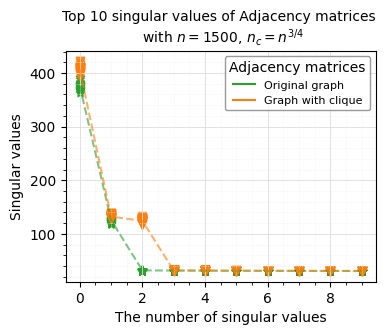

In [63]:
# no cluster RDPG

indexs = np.arange(0,10)

fig, ax = plt.subplots(figsize=(4, 3))

ax.grid(True)
ax.grid(which='major', color='#DDDDDD', linewidth=0.6)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.set_xlabel('The number of singular values')
ax.set_ylabel('Singular values')
ax.set_title('Top 10 singular values of Adjacency matrices \n with $n = 1500$, $n_c=n^{3/4}$',
             fontsize=10)

for i in range(singdata_a0.shape[0]-50,singdata_a0.shape[0]):
    plt.scatter(indexs,singdata_a0.iloc[i, :10],alpha = 0.8, 
                marker = '*',color = '#2ca02c')#,label = 'Original Graph')
    
for i in range(singdata_a1.shape[0]-50,singdata_a1.shape[0]):
    plt.scatter(indexs,singdata_a1.iloc[i, :10],alpha = 0.6,
                marker = 'v',color = '#ff7f0e')#,label = 'Graph with clique')

plt.plot(indexs.T, mean_1500_a0.T, linestyle = 'dashed',alpha = 0.6,
         color = '#2ca02c',label = 'Original graph')
plt.plot(indexs.T, mean_1500_a1.T, linestyle = 'dashed',alpha = 0.6,
         color = '#ff7f0e',label = 'Graph with clique')

lline = mlines.Line2D([], [], color='#2ca02c',
                          markersize=0, label='Original graph')
lline2 = mlines.Line2D([], [], color='#ff7f0e',
                          markersize=0, label='Graph with clique')


legend = plt.legend(frameon = 1,loc = 1,title="Adjacency matrices",
                    fontsize=8,fancybox=True,handles=[lline,lline2])
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')

#plt.show()
plt.savefig('./plots/singular/A0A1_n^34.png',bbox_inches='tight')



In [66]:
# 3 cluster RDPG
# read the singular value data
singdata_a0 = pd.read_csv ('./sim_data/singular/3rdpgsing_A0_logn.csv',sep=',',header = 0)
singdata_a0.rename({'10': "n"},axis=1, inplace=True)
print(singdata_a0.tail(2))
singdata_a1 = pd.read_csv ('./sim_data/singular/3rdpgsing_A1_logn.csv',sep=',',header = 0)
singdata_a1.rename({'10': "n"},axis=1, inplace=True)
print(singdata_a1.tail(2))
# generate mean values for the singular value
meandf_a0 = pd.DataFrame(singdata_a0.groupby(['n']).mean())
mean_1500_a0 = np.array(meandf_a0.iloc[[7]])
mean_1500_a0.T.shape
meandf_a1 = pd.DataFrame(singdata_a1.groupby(['n']).mean())
mean_1500_a1 = np.array(meandf_a1.iloc[[7]])
mean_1500_a1.T.shape

              0           1          2          3          4          5  \
398  374.612625  128.549665  31.923570  31.553333  31.247218  31.150495   
399  381.004131  125.154511  32.198094  32.015843  31.820939  31.476889   

             6          7          8          9       n  
398  30.979601  30.932418  30.883872  30.749454  1500.0  
399  31.150292  31.104333  30.968983  30.935389  1500.0  
              0           1          2          3          4          5  \
398  374.600937  128.047563  31.905322  31.790580  31.395555  31.275394   
399  382.466733  126.736714  32.075642  31.822213  31.789331  31.568963   

             6          7          8          9       n  
398  31.193223  31.086453  31.011848  30.907323  1500.0  
399  31.459198  31.363990  31.206181  31.157096  1500.0  


(10, 1)

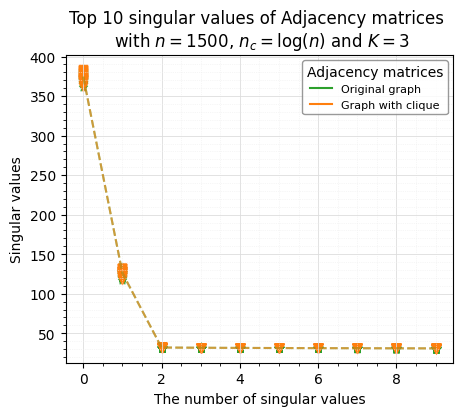

In [67]:
# 3 cluster RDPG

indexs = np.arange(0,10)

fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(True)
ax.grid(which='major', color='#DDDDDD', linewidth=0.6)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.set_xlabel('The number of singular values')
ax.set_ylabel('Singular values')
ax.set_title('Top 10 singular values of Adjacency matrices \n with $n = 1500$, $n_c=\log(n)$ and $K = 3$',
             fontsize=12)

for i in range(singdata_a0.shape[0]-50,singdata_a0.shape[0]):
    plt.scatter(indexs,singdata_a0.iloc[i, :10],alpha = 0.8, 
                marker = '*',color = '#2ca02c')#,label = 'Original Graph')
    
for i in range(singdata_a1.shape[0]-50,singdata_a1.shape[0]):
    plt.scatter(indexs,singdata_a1.iloc[i, :10],alpha = 0.8,
                marker = 'v',color = '#ff7f0e')#,label = 'Graph with clique')

plt.plot(indexs.T, mean_1500_a0.T,linestyle = 'dashed',alpha = 0.6,
         color = '#2ca02c',label = 'Original graph')
plt.plot(indexs.T, mean_1500_a1.T, linestyle = 'dashed',alpha = 0.6,
         color = '#ff7f0e',label = 'Graph with clique')

lline = mlines.Line2D([], [], color='#2ca02c',
                          markersize=0, label='Original graph')
lline2 = mlines.Line2D([], [], color='#ff7f0e',
                          markersize=0, label='Graph with clique')

legend = plt.legend(frameon = 1,loc = 1,title="Adjacency matrices",
                    fontsize=8,fancybox=True,handles=[lline,lline2])
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')



#plt.show()
#plt.savefig('./plots/singular/3A0A1_logn.png')



# draw the distance plots

In [64]:
# CAUTION 
# read dataset
readdata = pd.read_csv ('./sim_data/singular/sing_rdpgno_n^34n341500.csv',sep=',',header = 0)
#distdf = readdata[['ASE_dist','GEE_dist','n','VGAE_Fnorm']]
distdf = readdata[['ASE_dist','GEE_dist','n','VGAE_Fnorm','GEE_dist2']]
meltdf = pd.melt(distdf, id_vars=['n'], var_name='variable', value_name='value')
summary_functions = {'value': ['min', 'mean', 'max', 'std']}
finaldf = meltdf.groupby(['n', 'variable']).agg(summary_functions)
finaldf.columns = ['_'.join(col).strip() for col in finaldf.columns.values]
finaldf.reset_index(inplace=True)

readdata.head(3)


,ASE_dist,GEE_dist,VGAE_dist,ASE_nml,GEE_nml,GAE_nml,n,GEE_fnorm,VGAE_Fnorm,GEE_dist2,GEE_fnorm2,adj0_norms
0,4.799424,4.996572,1.617984,0.100645,0.104780,0.033930,100.0,5.880619,4.342203,7.949419,9.942705,47.686476
1,4.659933,5.998013,2.976838,0.098591,0.126901,0.062982,100.0,6.984383,5.656343,8.066317,10.521456,47.265209
2,5.019607,4.135940,1.656363,0.108105,0.089074,0.035672,100.0,4.488229,6.141462,8.069486,9.983793,46.432747


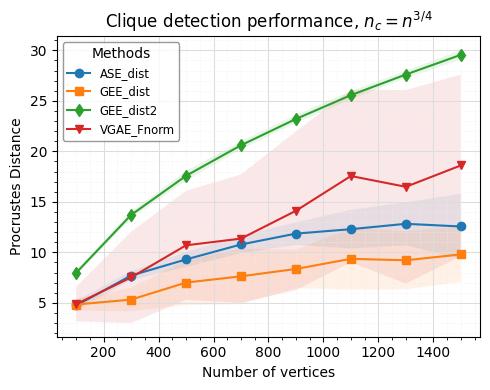

In [67]:
# CAUTION

fig, ax = plt.subplots(figsize=(5, 4))
#fig.patch.set_facecolor("#fafafa")
#ax.set_facecolor("#fafafa")

for item in [fig, ax]:
    item.patch.set_visible(True)

for variable, group in finaldf.groupby('variable'):
    ax.plot(group['n'], group['value_mean'], label=variable)
    ax.fill_between(group['n'], group['value_mean'] - group['value_std'], 
                    group['value_mean'] + group['value_std'], alpha=0.1)
    ax.grid(True)
    ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
    ax.minorticks_on()
    

ax.set(xlabel='Number of vertices', ylabel='Procrustes Distance', 
       title='Clique detection performance, $n_c =n^{3/4}$')#+cliquesize)
# ax.set_facecolor("white")

# set markers
#markers = ['o', 's', 'd','v','x','8']
markers = ['o', 's', 'd','v','x']
for i, line in enumerate(ax.get_lines()):
    line.set_marker(markers[i])

#ax.legend(ax.get_lines(), finaldf.columns, loc='upper left', ncol=2)

plt.tight_layout()

legend = plt.legend(frameon = 1,loc = 2,title="Methods",fontsize='small',fancybox=True )
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')

#plt.show()
#plt.savefig('./plots/singular/sin_n^34.png')


In [68]:
# get the normalized sub datafile
#nmldf = test[['ASE_nml','VGAE_Fnml','GEE_nml','GEE_nml2','n']]
readdata['GEE_nml2']=readdata['GEE_dist2']/readdata['adj0_norms']
readdata['VGAE_Fnml']=readdata['VGAE_Fnorm']/readdata['adj0_norms']
nmldf = readdata[['ASE_nml','VGAE_Fnml','GEE_nml','GEE_nml2','n']]
#nmldf = readdata[['ASE_nml','VGAE_Fnml','GEE_nml','n']]

meltdf = pd.melt(nmldf, id_vars=['n'], var_name='variable', value_name='value')
summary_functions = {'value': ['min', 'mean', 'max', 'std']}
finaldf = meltdf.groupby(['n', 'variable']).agg(summary_functions)
finaldf.columns = ['_'.join(col).strip() for col in finaldf.columns.values]
finaldf.reset_index(inplace=True)

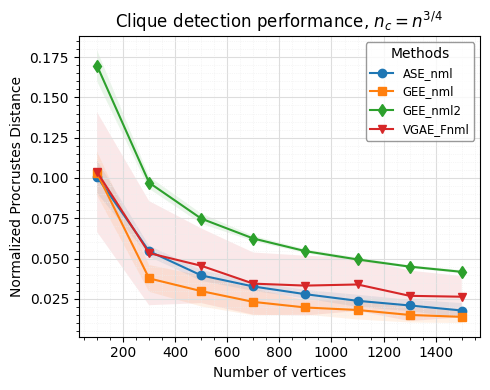

In [70]:
# CAUTION
# for normalized plots
fig, ax = plt.subplots(figsize=(5, 4))
#fig.patch.set_facecolor("#fafafa")
#ax.set_facecolor("#fafafa")

for item in [fig, ax]:
    item.patch.set_visible(True)

for variable, group in finaldf.groupby('variable'):
    ax.plot(group['n'], group['value_mean'], label=variable)
    ax.fill_between(group['n'], group['value_mean'] - group['value_std'], 
                    group['value_mean'] + group['value_std'], alpha=0.1)
    ax.grid(True)
    ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
    ax.minorticks_on()
    

ax.set(xlabel='Number of vertices', ylabel='Normalized Procrustes Distance', 
       title='Clique detection performance, $n_c = n^{3/4}$')   #+cliquesize) $$$$$$$$$$$$$$$$$$$$$$
# ax.set_facecolor("white")

# set markers
markers = ['o', 's', 'd','v','x','8']
#markers = ['o', 's', 'd','v']
#markers = ['o', 's', 'd']
for i, line in enumerate(ax.get_lines()):
    line.set_marker(markers[i])

#ax.legend(ax.get_lines(), finaldf.columns, loc='upper left', ncol=2)

plt.tight_layout()

legend = plt.legend(frameon = 1,loc = 1,title="Methods",fontsize='small',fancybox=True )
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')


#plt.show()
#plt.savefig('./plots/singular/sin_n^34_nml.png')


# row sum diff 

In [120]:
# no cluster RDPG
# R^2 and R^3
# calculate row sum
# latent clique

# nvs = np.arange(100, 1501, 200 )
nvs = np.arange(1000, 1001, 2)

sim = 50 ## change the sim number
random.seed(118)

ASE_dist = []
ASE_nml = []
GEE_dist = []
GEE_nml = []
GAE_dist = []
GAE_nml = []
n_vs = []

GEE_fnorm = []
GAE_fnorm = []

GEE_dist2 = []
GEE_fnorm2=[]

adj0_norms = []

singVs_A0 = []
singVs_A1 = []

A0_singvs = []
A1_singvs = []

sim_alldata_nml = []

RSD_afterASE = []
RSD_afterGEE1 = []
RSD_afterGEE2 = []
RSD_afterGAE = []

d = 2

for n in nvs:
    ########## find the clique vertices ##################################
    ratio = 0.2      
    cliquesize =f'{ratio}*n' #    !!    f'{ratio}*n'  f'log(n)^2'
    clique_size =  ratio*n   #math.log(n)           #   ratio*n  math.sqrt(n)  n**(3/4) 
    num_vertices = int(clique_size) 
    #################  change location of vertices##################
    #c_vertices = np.arange(0,num_vertices)  
    #c_vertices = np.arange(n-num_vertices,n)  
    c_vertices = random.sample(range(0,n),num_vertices)
    MRRs1,MRRs2,MRRs3,MRRs4 = [], [], [], []
    for i in range(sim):
        lpvs = np.random.dirichlet((1,1,1),n) 
        lpvs = np.delete(lpvs, 2, 1)
        g = rdpg(lpvs,loops=False)
        g.astype(int)
        adj0 = csr_array(g)
        graph0 = nx.from_numpy_matrix(g,parallel_edges=False, create_using=None)
        
        adj0_norm = sp.linalg.norm(adj0)
        adj0_norms.append(adj0_norm)
        
        adj0 = nx.to_numpy_array(graph0, dtype=int)

#         ########## find the clique vertices ##################################
#         ratio = 0.2      
#         cliquesize =f'{ratio}*n' #    !!    f'{ratio}*n'  f'log(n)^2'
#         clique_size = ratio*n     #math.log(n)           #   ratio*n 
#         num_vertices = int(clique_size) 
#         #################  change location of vertices##################
#         #c_vertices = np.arange(0,num_vertices)  
#         #c_vertices = np.arange(n-num_vertices,n)  
#         c_vertices = random.sample(range(0,n),num_vertices)
        ################################################################
        # generate the new latent position matrix with cliques
        lpvs_c = np.empty((lpvs.shape[0], lpvs.shape[1] + 1), dtype=lpvs.dtype)
        lpvs_c[:, :lpvs.shape[1]] = lpvs
        lpvs_c[:,2] = 0
        for i in c_vertices:
            lpvs_c[i][2] = math.sqrt(1-lpvs[i][0]**2-lpvs[i][1]**2)
            #print(lpvs_c[i])
        
        g2 = rdpg(lpvs_c,loops=False)
        g2.astype(int)
        #adj1 = csr_array(g2)
        graph1 = nx.from_numpy_matrix(g2,parallel_edges=False, create_using=None)
        adj1 = nx.to_numpy_array(graph1, dtype=int)

        ##############  ASE  ######################3
        d = d
        ase = AdjacencySpectralEmbed(n_components=d, algorithm='truncated')
        ASE_Xhat0 = ase.fit_transform(adj0)

        ASE_Xhat1 = ase.fit_transform(adj1)

        #pairplot(Xhat0, title='2-component embedding', height=2)
        ASE_d = procrustes(ASE_Xhat1,ASE_Xhat0)
        ASE_dd = ASE_d['error']
        ASE_dist.append(ASE_dd)
        
        ASE_n = ASE_dd/adj0_norm
        ASE_nml.append(ASE_n)
        
        ############## row sum after ASE
        
        row_1 = np.sum((ASE_Xhat0 - ASE_Xhat1.dot(ASE_d['W']))**2, axis=1)
        RSD_afterASE.append(row_1)


        ############ GEE ##################
        edgelist0 = adj_to_edg(adj0)
        i_graph0 = ig.Graph.from_networkx(graph0)
        y0 = la.find_partition(i_graph0, la.ModularityVertexPartition)
        #y0 = la.find_partition(i_graph0,la.CPMVertexPartition,resolution_parameter = 0.015)
        label_num = []
        for k in range(len(y0)):
            y = len(y0[k])
            label_num.append(y)
        values = np.arange(len(label_num))
        label0 = np.repeat(values, label_num) 
        label0= label0.reshape((n,1))
        Z0,W0 = graph_encoder_embed(edgelist0,label0,n,correlation=False)

        edgelist1 = adj_to_edg(adj1)
        i_graph1 = ig.Graph.from_networkx(graph1)
        n_comms = len(label_num)
        y1 = la.CPMVertexPartition(i_graph1,initial_membership=np.random.choice(n_comms, n),
                           resolution_parameter=0.5)
        
        label_num1 = []
        for j in range(len(y1)):
            y = len(y1[j])
            label_num1.append(y)
        values1 = np.arange(len(label_num1))
        label1 = np.repeat(values1, label_num1) 
        label1= label1.reshape((n,1))
        Z1,W1 = graph_encoder_embed(edgelist1,label1,n,correlation=False) #!!!!!!!!!!!!!!!!

        GEE_d = procrustes(Z1,Z0)
        GEE_dt = GEE_d['error']
        GEE_dist.append(GEE_dt)
        
        GEE_n = GEE_dt/adj0_norm
        GEE_nml.append(GEE_n)
        
        GEE_fd = np.linalg.norm(Z0 - Z1, "fro")
        GEE_fnorm.append(GEE_fd)
        
        y000 = la.find_partition(i_graph0,la.CPMVertexPartition,resolution_parameter = 0.4)
        label_numppp = []
        for k in range(len(y000)):
            y = len(y000[k])
            label_numppp.append(y)
        values = np.arange(len(label_numppp))
        label000 = np.repeat(values, label_numppp) 
        label000= label000.reshape((n,1))
        Z000,W000 = graph_encoder_embed(edgelist0,label000,n,correlation=False)#,emb_opt='AEE')

        edgelist1 = adj_to_edg(adj1)
        i_graph1 = ig.Graph.from_networkx(graph1)
        n_comms = len(label_numppp)
        y111 = la.CPMVertexPartition(i_graph1,initial_membership=np.random.choice(n_comms, n),
                           resolution_parameter=0.5)
        
        label_num1ttt = []
        for j in range(len(y111)):
            y = len(y111[j])
            label_num1ttt.append(y)
        values1 = np.arange(len(label_num1ttt))
        label111 = np.repeat(values1, label_num1ttt) 
        label111= label111.reshape((n,1))
        Z111,W111 = graph_encoder_embed(edgelist1,label111,n,correlation=False) #!!!!!!!!!!!!!!!!!!!!
        
        GEE_dd = procrustes(Z111,Z000)
        GEE_ddd = GEE_dd['error']
        GEE_dist2.append(GEE_ddd)

        GEE_fd2 = np.linalg.norm(Z000 - Z111, "fro")
        GEE_fnorm2.append(GEE_fd2)
        
        ############## row sum after GEE
        
        row_2 = np.sum((Z0 - Z1.dot(GEE_d['W']))**2, axis=1)
        RSD_afterGEE1.append(row_2)
        
        row_3 = np.sum((Z000 - Z111.dot(GEE_dd['W']))**2, axis=1)
        RSD_afterGEE2.append(row_3)
        
        ############### VGAE ################
        dim = d
        features = torch.eye(n)
        model_GAE = GCNModelVAE(n, 2*dim, dim, 0) #init new instance everytime. Can change 0 to other dropout rates
        
        adj0 = nx.to_numpy_array(graph0, dtype=int)
        adj_norm_matrix0, adj_matrix0, adj_label0 = adj_in_out(adj0)
        GAE_0 = GCN_emb(model_GAE, features, adj_norm_matrix0, adj_label0,n,decay=0, learning_rate=1e-2) #initial benchmark: decay = 1e-3; investigate 0 weight decay w/ dropout on 
        GAE_0 = GAE_0.numpy()
        adj1 = nx.to_numpy_array(graph1, dtype=int)
        adj_norm_matrix1, adj_matrix1, adj_label1 = adj_in_out(adj1)
        GAE_1 = GCN_emb(model_GAE, features, adj_norm_matrix1, adj_label1,n,decay=0, learning_rate=1e-2) #initial benchmark: decay = 1e-3; investigate 0 weight decay w/ dropout on 
        GAE_1 = GAE_1.numpy()
#         GAE_d = procrustes(GAE_1,GAE_0)
#         GAE_d = GAE_d['error']
#         GAE_dist.append(GAE_d)
        
#         GAE_n = GAE_d/adj0_norm
#         GAE_nml.append(GAE_n)
        
#         GAE_fd = np.linalg.norm(GAE_0 - GAE_1, "fro")
#         GAE_fnorm.append(GAE_fd)
        
        n_vs.append(n)
        
        row_4 = np.sum((GAE_0 - GAE_1)**2, axis=1)
        RSD_afterGAE.append(row_4)        
#------------------------ MRRS
        sorted_indices1 = np.argsort(row_1)[::-1]
        sorted_indices2 = np.argsort(row_2)[::-1]
        sorted_indices3 = np.argsort(row_3)[::-1]
        sorted_indices4 = np.argsort(row_4)[::-1]
        ranks1 = []
        ranks2 = []
        ranks3 = []
        ranks4 = []
        for v in c_vertices:
            rank1 = np.where(sorted_indices1 == v)[0][0] + 1  # 1-based index
            ranks1.append(rank1)
            rank2 = np.where(sorted_indices2 == v)[0][0] + 1
            ranks2.append(rank2)
            rank3 = np.where(sorted_indices3 == v)[0][0] + 1
            ranks3.append(rank3)
            rank4 = np.where(sorted_indices4 == v)[0][0] + 1
            ranks4.append(rank4)

        reciprocals1 = [1 / r for r in ranks1]
        reciprocals2 = [1 / r for r in ranks2]
        reciprocals3 = [1 / r for r in ranks3]
        reciprocals4 = [1 / r for r in ranks4]
        MRRs1.append(np.mean(reciprocals1))
        MRRs2.append(np.mean(reciprocals2))
        MRRs3.append(np.mean(reciprocals3))
        MRRs4.append(np.mean(reciprocals4))

#----------------------------
#         ########################### get singular values of A0 and A1
#         u0,s0,vh0 = np.linalg.svd(adj0,full_matrices=True)
#         singVs_A0.append(np.append(s0[0:10],n))
        
#         u1,s1,vh1 = np.linalg.svd(adj1,full_matrices=True)
#         singVs_A1.append(np.append(s1[0:10],n))
        
           
#     sim_data = np.column_stack((ASE_dist, GEE_dist,GAE_dist,
#                                 ASE_nml,GEE_nml,GAE_nml,n_vs,
#                                 GEE_fnorm,GAE_fnorm,GEE_dist2,GEE_fnorm2,adj0_norms))
#     sim_data = pd.DataFrame(sim_data, columns = ['ASE_dist','GEE_dist','VGAE_dist',
#                                                  'ASE_nml','GEE_nml','GAE_nml','n',
#                                                  'GEE_fnorm','VGAE_Fnorm','GEE_dist2','GEE_fnorm2','adj0_norms'])
    
#     df_id = n.astype(str)
#     sim_data.to_csv("./sim_data/singular/sing_rdpgno_log2"+cliquesize+df_id+".csv", sep=',', index=False)
    
# sim_alldata_nml.append(sim_data)
    
# SV_A0 = np.reshape(singVs_A0,(sim*len(nvs),11))
# SV_A1 = np.reshape(singVs_A1,(sim*len(nvs),11))
    
# A0_singvs.append(SV_A0)
# A1_singvs.append(SV_A1)
# tt = np.reshape(A0_singvs,(sim*len(nvs),11))
# singvalue_a0 = pd.DataFrame(tt)
# #singvalue_a0.to_csv("./sim_data/singular/sing_A0_02n.csv", sep=',', index=False)
# pp = np.reshape(A1_singvs,(sim*len(nvs),11))
# singvalue_a1 = pd.DataFrame(pp)
# #singvalue_a1.to_csv("./sim_data/singular/sing_A1_02n.csv", sep=',', index=False)
# print(sim_alldata_nml)
# print(A0_singvs)
# print(A1_singvs)


GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): GraphConvolution (1000 -> 4)
  (gc2): GraphConvolution (4 -> 2)
  (gc3): GraphConvolution (4 -> 2)
  (dc): InnerProductDecoder()
)
not converged yet, reset params and rerun
GCNModelVAE(
  (gc1): Gra

In [121]:
# print MRRs
print(np.mean(MRRs1) )
print(np.mean(MRRs2))
print(np.mean(MRRs3))
print(np.mean(MRRs4))

0.028209968617432395
0.0062286158317314995
0.016673105199541547
0.026880727747677288


In [55]:
test1 = []
for x in RSD_afterASE:
    tt = np.sort(x)
    test1.append(tt)

p1=np.mean(test1,axis=0)
sortedASE = np.sort(p1)[::-1]

indexs = list(range(len(sortedASE)))

test2 = []
for x in RSD_afterGEE1:
    tt = np.sort(x)
    test2.append(tt)

p2=np.mean(test2,axis=0)
sorted_GEE1 = np.sort(p2)[::-1]
    
test3 = []
for x in RSD_afterGEE2:
    tt = np.sort(x)
    test3.append(tt)

p3=np.mean(test3,axis=0)
sorted_GEE2 = np.sort(p3)[::-1]

test4 = []
for x in RSD_afterGAE:
    tt = np.sort(x)
    test4.append(tt)

p4=np.mean(test4,axis=0)
sorted_GAE = np.sort(p4)[::-1]
    

In [122]:
#### 8/27 average then sort and highlight the stars
# Compute average RSD directly, no sorting first
p1 = np.mean(RSD_afterASE, axis=0)
p2 = np.mean(RSD_afterGEE1, axis=0)
p3 = np.mean(RSD_afterGEE2, axis=0)
p4 = np.mean(RSD_afterGAE, axis=0)


sortedASE = np.sort(p1)[::-1]
sorted_indices = np.argsort(p1)[::-1] 
highlight_positions_p1 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p1 = [sortedASE[i] for i in highlight_positions_p1]


sorted_GEE1 = np.sort(p2)[::-1]
sorted_indices = np.argsort(p2)[::-1] 
highlight_positions_p2 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p2 = [sorted_GEE1[i] for i in highlight_positions_p2]


sorted_GEE2 = np.sort(p3)[::-1]
sorted_indices = np.argsort(p3)[::-1] 
highlight_positions_p3 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p3 = [sorted_GEE2[i] for i in highlight_positions_p3]


sorted_GAE = np.sort(p4)[::-1]
sorted_indices = np.argsort(p4)[::-1] 
highlight_positions_p4 = [i for i, idx in enumerate(sorted_indices) if idx in c_vertices]
highlight_values_p4 = [sorted_GAE[i] for i in highlight_positions_p4]

# Indices for plotting (after final sort)
indexs = list(range(len(sortedASE)))


In [49]:
# CAUTION store vaelus
Xc_r2_02n = [test1,test2,test3,test4]

In [43]:
# CAUTION store vaelus
Xc_r3_02n = [test1,test2,test3,test4]

In [34]:
# CAUTION store vaelus
Xc_r3_logn = [RSD_ASE,RSD_GEE1,RSD_GEE2,RSD_GAE]

In [54]:
# CAUTION store vaelus
Xc_r2_logn = [test1,test2,test3,test4]

In [16]:
# draw the zoomed part 
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset,inset_axes

zoomase = sortedASE[0:50]
indexzoom = list(range(len(zoomase)))



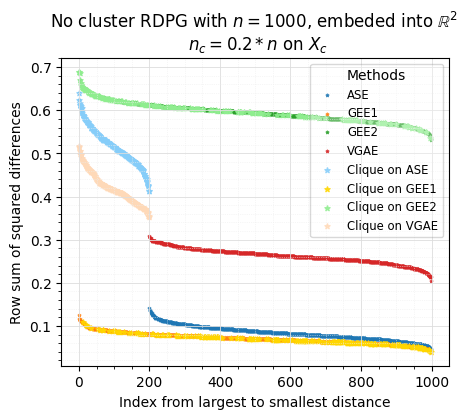

In [123]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.grid(True)
ax.grid(which='major', color='#DDDDDD', linewidth=0.6)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
ax.minorticks_on()
ax.set_xlabel('Index from largest to smallest distance')
ax.set_ylabel('Row sum of squared differences')
ax.set_title('No cluster RDPG with $n=1000$, embeded into $\mathbb{R}^2$ \n $n_c =0.2*n$ on $X_c$', ###___n^{3/4}  \sqrt{n}
             fontsize=12)

plt.scatter(indexs,sortedASE,marker = '*',color = '#1f77b4',alpha = 0.8,s = 4,label = "ASE")
plt.scatter(indexs,sorted_GEE1,marker = '*',color = '#ff7f0e',alpha = 0.8,s = 4,label = "GEE1")
plt.scatter(indexs,sorted_GEE2,marker = '*',color = '#2ca02c',alpha = 0.8,s = 4,label = 'GEE2')
plt.scatter(indexs,sorted_GAE,marker = '*',color = '#d62728',alpha = 0.8,s = 4,label = "VGAE")

# 8/27/2025 added started parts
#---------------
plt.scatter(highlight_positions_p1, highlight_values_p1,
            marker='*', color='lightskyblue', s=15,alpha = 0.8,label='Clique on ASE')# label='C vertices')
plt.scatter(highlight_positions_p2, highlight_values_p2,
            marker='*', color='gold', s=15,alpha = 0.8,label='Clique on GEE1')# label='C vertices')
plt.scatter(highlight_positions_p3, highlight_values_p3,
            marker='*', color='lightgreen', s=15,alpha = 0.8,label='Clique on GEE2')# label='C vertices')
plt.scatter(highlight_positions_p4, highlight_values_p4,
            marker='*', color='peachpuff', s=15,alpha = 0.8,label='Clique on VGAE')# label='C vertices')

#---------------

legend = plt.legend(frameon = 1,loc = 1,title="Methods",
                    fontsize='small',fancybox=True)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('grey')
frame.set_alpha(0.3)

# a = plt.axes([0.3, 0.6, .2, .2], facecolor='w')
# plt.scatter(indexzoom,zoomase,marker = '*',color = '#1f77b4',alpha = 0.8)
# plt.title('Zoomed ASE',fontsize = 'small')
# plt.xticks([])
# plt.yticks([])
# mark_inset(ax, a, loc1=2, loc2=4, fc="none", ec="0.6")

# # === Inset (zoomed-in plot) ===
# axins = inset_axes(ax, width="40%", height="40%", loc='upper left',
#                    bbox_to_anchor=(0.25, 0.35, 0.4, 0.4), bbox_transform=ax.transAxes)
# # zoom region: first 50 points
# zoom_range = slice(0, 50)
# zoom_x = indexs[zoom_range]
# zoom_y = sortedASE[zoom_range]
# # Highlighted points within zoom
# zoom_highlight_x = [i for i in highlight_positions_p1 if i < 50]
# zoom_highlight_y = [sortedASE[i] for i in zoom_highlight_x]
# # Inset plot
# axins.scatter(zoom_x, zoom_y, marker='*', color='#1f77b4', alpha=0.8, s=8)
# axins.scatter(zoom_highlight_x, zoom_highlight_y, marker='*', color='lightskyblue', s=20)
# axins.set_xticks([])
# axins.set_yticks([])
# # Connect inset to main plot
# mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.6")

# plt.savefig('./plots/rowsum/Xc_r2_02n_zoom_stars.png')  #  Xc_r2_sqrtn_zoom Xc_r3_n34_zoom
# plt.show()


In [108]:
print(d)
print(clique_size)

2
177.82794100389228
